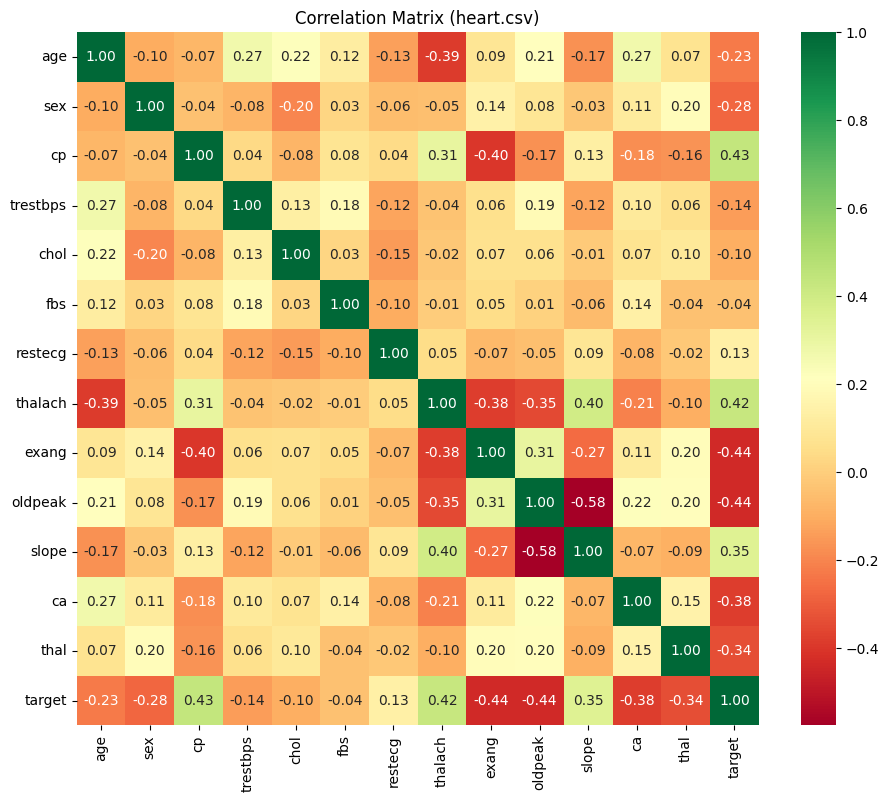

/tmp/ipython-input-979086741.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rfe_ranking.values, y=rfe_ranking.index, palette='magma')


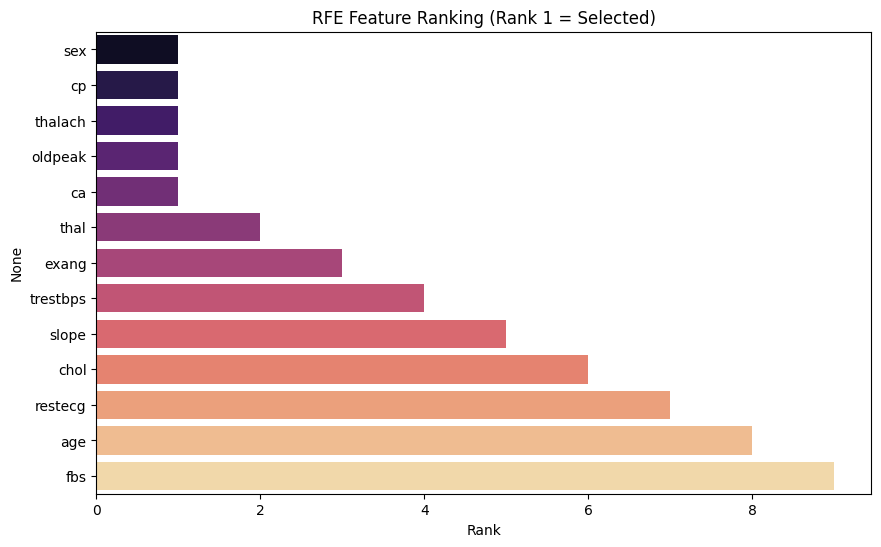

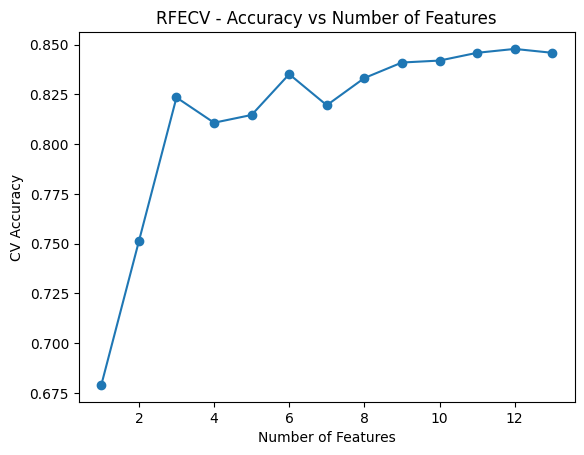

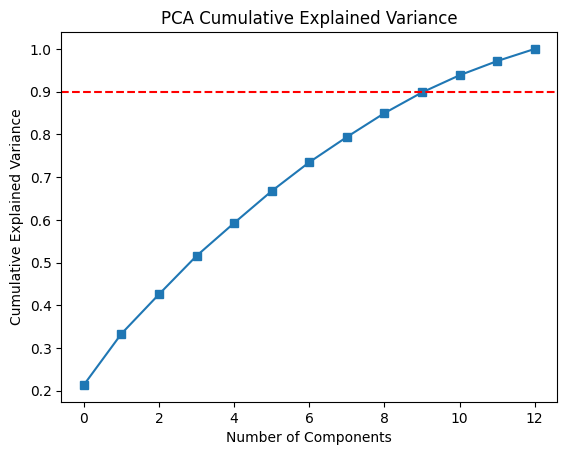

Optimal features by RFECV: 12
Top 5 RFE features: ['sex', 'cp', 'thalach', 'oldpeak', 'ca']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, RFE, RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

# ۱. بارگذاری داده‌های ارسالی
df = pd.read_csv('heart.csv')
X = df.drop('target', axis=1)
y = df['target']
feature_names = X.columns

# استانداردسازی
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_names)

# الف) ماتریس همبستگی
plt.figure(figsize=(11, 9))
sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Correlation Matrix (heart.csv)")
plt.savefig('q8_corr.png')
plt.show()

# ب) انتخاب تک‌متغیره (Mutual Information)
mi_scores = mutual_info_classif(X_scaled, y, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_names).sort_values(ascending=False)

# ج) روش Wrapper (RFE) - نمودار رتبه‌بندی اضافه شد
model = LogisticRegression(solver='liblinear', random_state=42)
rfe = RFE(estimator=model, n_features_to_select=5)
rfe.fit(X_scaled, y)

# استخراج رتبه‌بندی برای نمودار
rfe_ranking = pd.Series(rfe.ranking_, index=feature_names).sort_values()
plt.figure(figsize=(10, 6))
sns.barplot(x=rfe_ranking.values, y=rfe_ranking.index, palette='magma')
plt.title("RFE Feature Ranking (Rank 1 = Selected)")
plt.xlabel("Rank")
plt.savefig('q8_rfe_ranking.png')
plt.show()

# د) روش Wrapper (RFECV)
rfecv = RFECV(estimator=model, step=1, cv=StratifiedKFold(5), scoring='accuracy')
rfecv.fit(X_scaled, y)

plt.figure()
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'], marker='o')
plt.title("RFECV - Accuracy vs Number of Features")
plt.xlabel("Number of Features")
plt.ylabel("CV Accuracy")
plt.savefig('q8_rfecv.png')
plt.show()

# ه) روش Embedded (Lasso)
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42).fit(X_scaled, y)

# و) تحلیل PCA
pca = PCA().fit(X_scaled)
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='s')
plt.axhline(y=0.9, color='r', linestyle='--')
plt.title("PCA Cumulative Explained Variance")
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.savefig('q8_pca.png')
plt.show()

print(f"Optimal features by RFECV: {rfecv.n_features_}")
print(f"Top 5 RFE features: {list(feature_names[rfe.support_])}")